In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

In [2]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution

## Getting more years for monthly series

In [85]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"
OUTPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

for i in range(3, 8):
    df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[i]), sep=",")
    df['year'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.year
    df['month'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.month
    df['year-month'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.strftime("%Y-%m")
    df = df[~df['year'].isin(df.groupby(df['year'])['precipitation original'].apply(lambda x: x.isna().sum()) > 74)]
    df['precipitation original'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values
    
    if len(df['year'].unique()) >= 18:
    
        df_test = df[df['year'].isin(df['year'].unique()[-3:])]
        df_train = df[~df['year'].isin(df['year'].unique()[-3:])]
        df_train.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_train.csv"), index = False)
        df_test.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_test.csv"), index = False)
        



In [86]:
INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\treated"
OUTPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab monthly"

for i in range(3):
    df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[i]), sep=";")
    df['year'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.year
    df['month'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.month
    df['year-month'] = pd.to_datetime(df['Data Medicao'], format = '%d/%m/%Y').dt.strftime("%Y-%m")
    df = df[~df['year'].isin(df.groupby(df['year'])['precipitation original'].apply(lambda x: x.isna().sum()) > 74)]
    df['precipitation original'].fillna(df['smoothed'], inplace=True)
    
    if len(df['year'].unique()) >= 18:
    
        df_test = df[df['year'].isin(df['year'].unique()[-3:])]
        df_train = df[~df['year'].isin(df['year'].unique()[-3:])]
        df_train.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_train.csv"), index = False)
        df_test.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_test.csv"), index = False)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\1551914727.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['precipitation original'].fillna(df['smoothed'], inplace=True)
C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\1551914727.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['9,923488149' '-0,09374049']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['precipitation original'].fill

In [94]:
dfs = []

for i, f in enumerate(os.listdir(OUTPUT)):
    if "_train" in f:
        df = pd.read_csv(os.path.join(OUTPUT, f), sep=";")
        if "precipitation original" in df.columns:
            df['precipitation original'].fillna(df['smoothed'].str.replace(",", ".").astype(float).apply(lambda x: x if x > 0 else 0), inplace=True)
        else:
            df = pd.read_csv(os.path.join(OUTPUT, f), sep=",")
            df['precipitation original'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values
            df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
            df['precipitation original'].fillna(df['smoothed'].apply(lambda x: x if x > 0 else 0), inplace=True)
        dfs.append(df)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3156648945.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['precipitation original'].fillna(df['smoothed'].apply(lambda x: x if x > 0 else 0), inplace=True)
C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3156648945.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

In [104]:
len(dfs)

6

0       2000
1       2000
2       2000
3       2000
4       2000
        ... 
8786    2026
8787    2026
8788    2026
8789    2026
8790    2026
Name: year, Length: 8791, dtype: int32

In [36]:
df = df[~df['year'].isin(df.groupby(df['year'])['precipitation original'].apply(lambda x: x.isna().sum()) > 74)]
df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).apply(lambda x: x if x > 0 else 0).values

In [37]:
df['precipitation original'].fillna(df['smoothed'], inplace=True)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3015750342.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['precipitation original'].fillna(df['smoothed'], inplace=True)


In [27]:
df['year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2016, 2017, 2018], dtype=int32)

## Models

In [46]:
y = df['precipitation original'].values

In [47]:
theta0 = np.concatenate([
    np.array([
        np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
        0.5,        # c_phi
        0.95,       # alpha_phi
        0.01,       # kappa_phi
        0.01,       # kappa_gamma_phi

        -1.0,       # omega0
        0.5,        # rho

        0.01, 0.01, 0.01,   # omega_y (K=3)

        1.2,        # gamma
        1.2,        # xi
        5.0         # zeta
    ]),
    np.zeros(12)        # gamma0_phi
])

bounds = [
    (-2.0, 4.0),     # mu0_phi
    (0.0, 5.0),      # c_phi
    (0.00, 0.995),   # alpha_phi
    (1e-4, 0.1),     # kappa_phi
    (1e-4, 0.1),     # kappa_gamma_phi

    (-10.0, 2.0),    # omega0
    (0.00, 0.99),   # rho

] + [(-5.0, 5.0)] * 3 + [   # omega_y

    (0.5, 2.5),      # gamma
    (0.5, 3.0),      # xi
    (2.5, 6.0)       # zeta

] + [(-0.5, 0.5)] * 12
res = minimize(
    objective_zagb2,
    theta0,
    args=(y, df['month'].values, 3, [],12),
    method="L-BFGS-B",
    bounds=bounds,
    options={
    "disp": True,
    "maxiter": 500,
    "gtol": 1e-3,
    "ftol": 1e-3
    }
)

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\1290387455.py:38: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


In [48]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)

In [49]:
from scipy.stats import norm
from statsmodels.tsa.stattools import acf

# ----------------------
# Extract parameters
# ----------------------


idx = 0
K = 3

mu0_phi = res.x[idx]; idx+=1
c_phi = res.x[idx]; idx+=1
alpha_phi = res.x[idx]; idx+=1
kappa_phi = res.x[idx]; idx+=1

# NO kappa_xi_tvp here

kappa_gamma_phi = res.x[idx]; idx+=1

omega0 = res.x[idx]; idx+=1
rho = res.x[idx]; idx+=1

omega_y = res.x[idx:idx+K]; idx+=K

gamma_init = res.x[idx]; idx+=1
xi_init = res.x[idx]; idx+=1
zeta_init = res.x[idx]; idx+=1

gamma0_phi = res.x[idx:idx+12]; idx+=12


    # ----------------------
    # Run filter
    # ----------------------

kappas_tvp = np.zeros(4)

out = iterate_zagb2(
    mu0_phi=mu0_phi,
    gamma0_phi=gamma0_phi - np.mean(gamma0_phi),  # enforce zero-sum
    alpha_phi=alpha_phi,
    kappa_phi=kappa_phi,
    kappas_tvp=kappas_tvp,
    c_phi=c_phi,
    kappa_gamma_phi=kappa_gamma_phi,
    omega0=omega0,
    rho=rho,
    omega_y=omega_y,
    gamma_init=gamma_init,
    xi_init=xi_init,
    zeta_init=zeta_init,
    period=12,
    y=y,
    months=df['month'].values,
    time_varying_parameters=[],
    mode="filter"
)

phi_hat = out["phi"]
pi_hat  = out["pi"]
gamma_hat = out["gamma"]
xi_hat = out["xi"]
zeta_hat = out["zeta"]
# ----------------------
# Compute PIT
# ----------------------

y_eff = y[K:]
pit = np.zeros(len(y_eff))
rng = np.random.default_rng(123)

for t in range(len(y_eff)):

    if y_eff[t] == 0:
        pit[t] = rng.uniform(0.0, 1.0 - pi_hat[t])
    else:
        F = gb2_cdf(
            y_eff[t],
            phi_hat[t],
            gamma_hat[t],
            xi_hat[t],
            zeta_hat[t]
        )
        pit[t] = (1 - pi_hat[t]) + pi_hat[t] * F

pit = np.clip(pit, 1e-10, 1 - 1e-10)
qr = norm.ppf(pit)   # ← FIXED


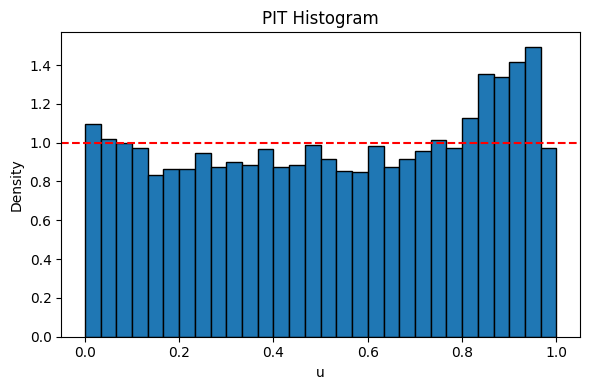

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

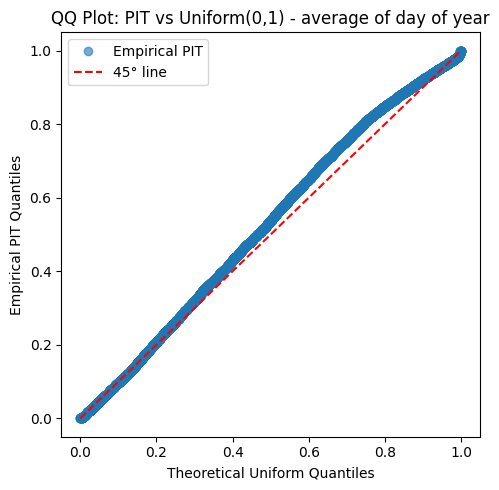

In [55]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - average of day of year")
plt.legend()
plt.tight_layout()
plt.show()

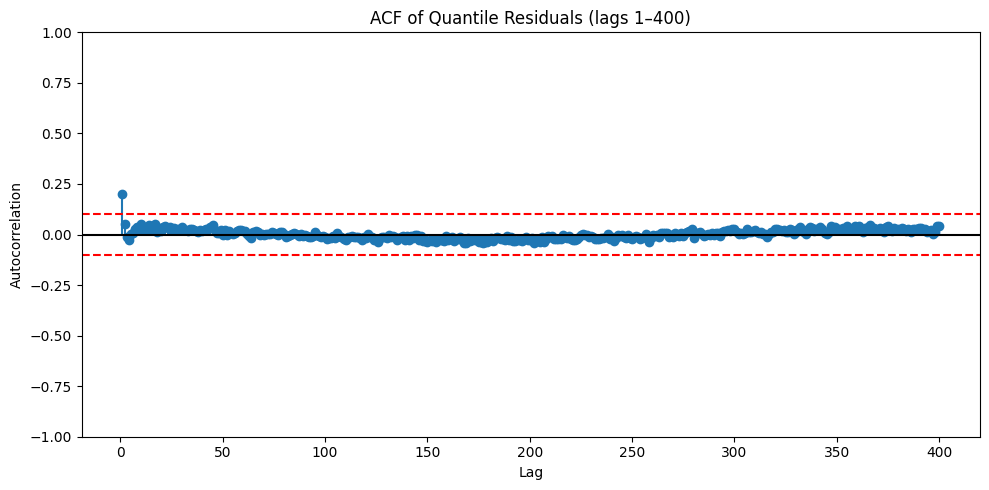

In [56]:
from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()

## ALL in

In [174]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    alpha_phi,
    kappa_phi,
    kappas_tvp,
    c_phi,
    kappa_gamma_phi,

    # GB2 shape (initial values)
    gamma_init,
    xi_init,
    zeta_init,

    period,
    y,
    months,
    time_varying_parameters,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t
    - Persistent ARX logit π_t
    - Optional TVP for (gamma, xi, zeta)
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    n_eff = T - K

    # ---------- Allocate ----------
    mu_phi = np.zeros(n_eff + 1)
    gamma_phi = np.zeros((n_eff + 1, period))
    kappa_gamma_curr = np.zeros((n_eff + 1, period))
    phi = np.zeros(n_eff)

    gamma = np.zeros(n_eff)
    xi = np.zeros(n_eff)
    zeta = np.zeros(n_eff)

    score_phi = np.zeros(n_eff)
    score_gamma = np.zeros(n_eff)
    score_xi = np.zeros(n_eff)
    score_zeta = np.zeros(n_eff)

    # ---------- Initial states ----------
    mu_phi[0] = mu0_phi
    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    gamma_phi[0, :] = gamma0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # ===== 1. Update TVP parameters FIRST =====
        if i > 0:
            gamma[i] = gamma[i-1]
            xi[i] = xi[i-1]
            zeta[i] = zeta[i-1]

            if 2 in time_varying_parameters:
                gamma[i] += kappas_tvp[1] * score_gamma[i-1]
            if 3 in time_varying_parameters:
                xi[i] += kappas_tvp[2] * score_xi[i-1]
            if 4 in time_varying_parameters:
                zeta[i] += kappas_tvp[3] * score_zeta[i-1]

        # validity
        if np.exp(zeta[i]) <= np.exp(gamma[i]):
            return 1e12

        # ===== 2. φ dynamics =====
        phi[i] = mu_phi[i] + gamma_phi[i, int(months[t] - 1)]


        if not np.isfinite(phi[i]):
            return 1e12

        # ===== 4. Likelihood =====
        if mode == "loglik":
            ll = gb2.logpdf(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            loglik += ll

            if not np.isfinite(ll):
                return 1e12

        # ===== 5. Scores =====
        if y[t] > 0:
            scores = gb2.score(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            score_phi[i], score_gamma[i], score_xi[i], score_zeta[i] = scores
        else:
            score_phi[i] = 0.0
            score_gamma[i] = 0.0
            score_xi[i] = 0.0
            score_zeta[i] = 0.0

        # ===== 6. GAS update for φ =====
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ===== 7. Seasonal φ =====
        
        kappa_gamma_curr[i, :] = [kappa_gamma_phi if j==(months[t] - 1) else -kappa_gamma_phi/(period - 1) for j in range(period)]
        gamma_phi[i+1, :] = gamma_phi[i] + [score_phi[i]*kappa_gamma_curr[i, j] for j in range(period)]

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [192]:
def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    alpha_phi,
    kappa_phi,
    kappas_tvp,
    c_phi,
    kappa_gamma_phi,

    # GB2 shape (initial values)
    gamma_init,
    xi_init,
    zeta_init,

    period,
    y,
    months,
    time_varying_parameters,
    mode="loglik"
):

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    n_eff = T

    # ---------- Allocate ----------
    mu_phi = np.zeros(n_eff + 1)
    gamma_phi = np.zeros((n_eff + 1, period))
    phi = np.zeros(n_eff)

    gamma = np.zeros(n_eff)
    xi = np.zeros(n_eff)
    zeta = np.zeros(n_eff)

    score_phi = np.zeros(n_eff)
    score_gamma = np.zeros(n_eff)
    score_xi = np.zeros(n_eff)
    score_zeta = np.zeros(n_eff)

    # ---------- Initial states ----------
    mu_phi[0] = mu0_phi
    gamma_phi[0, :] = gamma0_phi.copy()

    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    loglik = 0.0

    # ---------- Main loop ----------
    for t in range(T):

        # ===== 1. Construct φ_t (log scale) =====
        month_index = int(months[t] - 1)
        phi[t] = mu_phi[t] + gamma_phi[t, month_index]

        if not np.isfinite(phi[t]):
            return 1e12

        # ===== 2. Likelihood =====
        if mode == "loglik":
            ll = gb2.logpdf(
                y[t],
                phi=phi[t],
                gamma=gamma[t],
                xi=xi[t],
                zeta=zeta[t],
            )

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ===== 3. Score =====
        if y[t] > 0:
            s = gb2.score(
                y[t],
                phi=phi[t],
                gamma=gamma[t],
                xi=xi[t],
                zeta=zeta[t],
            )
        else:
            s = np.zeros(4)

        score_phi[t], score_gamma[t], score_xi[t], score_zeta[t] = s

        # ===== 4. Fisher Information (outer-product) =====
        I_t = np.outer(s, s)

        # Regularization (very important)
        I_t += 1e-6 * np.eye(4)

        try:
            I_inv = np.linalg.inv(I_t)
        except np.linalg.LinAlgError:
            return 1e12

        scaled_s = I_inv @ s
        scaled_score_phi = scaled_s[0]

        # ===== 5. GAS update for μ_phi =====
        mu_phi[t+1] = (
            c_phi
            + alpha_phi * mu_phi[t]
            + kappa_phi * scaled_score_phi
        )

        # ===== 6. Seasonal update =====
        kappa_vec = np.full(period, -kappa_gamma_phi / (period - 1))
        kappa_vec[month_index] = kappa_gamma_phi

        gamma_phi[t+1, :] = (
            gamma_phi[t]
            + scaled_score_phi * kappa_vec
        )

        # Enforce seasonal identification
        gamma_phi[t+1, :] -= np.mean(gamma_phi[t+1, :])

        # ===== 7. Carry forward static parameters =====
        if t + 1 < n_eff:
            gamma[t+1] = gamma[t]
            xi[t+1] = xi[t]
            zeta[t+1] = zeta[t]

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [193]:
def objective_zagb2(theta, y, months, tvp = [], period=12):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    if len(tvp) > 0:
        for i, v in enumerate(tvp): 
            kappas_tvp[v-1] = theta[idx]; idx += 1
    
    kappa_gamma_phi= theta[idx]; idx += 1

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+period]; idx += period

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        period=period,
        y=y,
        months = months,
        time_varying_parameters=tvp,
        mode="loglik"
    )


In [194]:
def AIC_zagb2(theta, y, months, tvp=[], period=12):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    if len(tvp) > 0:
        for i, v in enumerate(tvp): 
            kappas_tvp[v-1] = theta[idx]; idx += 1
    
    kappa_gamma_phi= theta[idx]; idx += 1

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+period]; idx += period

    loglik = -iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        period=period,
        y=y,
        months=months,
        time_varying_parameters=tvp,
        mode="loglik"
    )
    
    return 2 * (len(theta) - loglik)


In [105]:
dfs[5]

,Unnamed: 0,Data Medicao,"PRECIPITACAO TOTAL, DIARIO(mm)",Unnamed: 2,year,precipitation original,precipitation log,location,month,year-month,smoothed
0,0,01/01/2000,"16,8",NaN,2000,16.8,28.219.739.474.205.200,SÃO PAULO,1,2000-01,"11,78586974"
1,1,02/01/2000,"49,8",NaN,2000,49.8,3.908.215.767.085.190,SÃO PAULO,1,2000-01,"12,17140933"
2,2,03/01/2000,"14,8",NaN,2000,14.8,26.953.026.282.797.000,SÃO PAULO,1,2000-01,"11,8442973"
3,3,04/01/2000,"60,8",NaN,2000,60.8,4.107.754.249.132.010,SÃO PAULO,1,2000-01,"11,94375148"
4,4,05/01/2000,"6,3",NaN,2000,6.3,18.421.356.765.531.200,SÃO PAULO,1,2000-01,"10,98571012"
...,...,...,...,...,...,...,...,...,...,...,...
8030,8761,27/12/2023,"0,9",NaN,2023,0.9,-0.0943106794712412,SÃO PAULO,12,2023-12,"4,457027172"
8031,8762,28/12/2023,0,NaN,2023,0.0,-4.605.170.185.988.090,SÃO PAULO,12,2023-12,"4,62909931"
8032,8763,29/12/2023,0,NaN,2023,0.0,-4.605.170.185.988.090,SÃO PAULO,12,2023-12,"3,859423212"
8033,8764,30/12/2023,"3,6",NaN,2023,3.6,12.837.077.723.447.800,SÃO PAULO,12,2023-12,"4,529715467"


In [111]:
df.groupby('year-month')['precipitation original'].sum().values

array([ 29.5       ,  85.3       , 191.9       , 365.4       ,
       248.5       , 310.5       , 201.1       , 136.2       ,
       161.6       ,  15.9       ,  74.3       ,  88.        ,
        95.2       ,  28.6       , 264.1       , 103.5       ,
       199.2       , 195.9       , 220.3       , 149.7       ,
       190.8       , 202.3       ,  30.3       ,  97.4       ,
       252.4       , 102.8       , 102.1       ,  69.3       ,
       351.6       , 209.4       , 254.8       , 162.8       ,
       258.8       ,  16.        ,  25.2       ,  22.7       ,
        26.7       ,  97.3       , 206.3       , 186.8       ,
       550.5       , 237.5       , 186.5       , 136.7       ,
       168.7       ,  72.2       , 132.8       ,  15.2       ,
       319.4       , 165.3       , 121.9       , 278.4       ,
       159.5       , 326.3       , 218.4       , 129.5       ,
        40.5       ,  82.        , 167.6       ,  10.9       ,
        42.9       , 349.4       , 349.4       , 415.  

In [195]:
from scipy.optimize import minimize

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"
period = 12

aics = {}
results = {}

for i,df in enumerate(dfs):
    
    loc = df['location'].values[0]
    print("Working on " + loc)
    
    aics[loc] = []
    results[loc] = []

    y = df.groupby('year-month')['precipitation original'].sum().values
    months = df.groupby('year-month')['month'].mean().values
    
    y[y == 0] += 1.0
    
    
    for tvp in [[]]:#, [3]]:
        
        print("Model = " + str([1] + tvp))
        
        if len(tvp) > 0:
            theta0 = np.concatenate([
                np.array([
                    np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                    0.5,        # c_phi
                    0.95,       # alpha_phi
                    0.01,       # kappa_phi
                    *[0.01],#, 0.01],
                    0.01,       # kappa_gamma_phi
                    1.2,        # gamma
                    1.2,        # xi
                    5.0         # zeta
                ]),
                np.zeros(period),        # gamma0_phi
            ])
        
            bounds = [
                    (-2.0, 4.0),     # mu0_phi
                    (0.0, 5.0),      # c_phi
                    (0.00, 0.995),   # alpha_phi
                    (1e-4, 0.1),     # kappa_phi
                    *[(1e-4, 0.1)],#, (1e-4, 0.1)],#, (-0.1, 0.1), (-0.1, 0.1)],
                    (1e-4, 0.1),     # kappa_gamma_phi
                    (0.5, 2.5),      # gamma
                    (0.5, 3.0),      # xi
                    (2.5, 6.0)       # zeta

                ] + [(-0.5, 0.5)] * period
            
            
        else:
            theta0 = np.concatenate([
                np.array([
                    np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                    0.5,        # c_phi
                    0.95,       # alpha_phi
                    0.01,       # kappa_phi
                    0.01,       # kappa_gamma_phi
                    1.2,        # gamma
                    1.2,        # xi
                    5.0         # zeta
                ]),
                np.zeros(period)        # gamma0_phi
            ])
        
            bounds = [
                    (-2.0, 4.0),     # mu0_phi
                    (0.0, 5.0),      # c_phi
                    (0.00, 0.995),   # alpha_phi
                    (1e-4, 0.1),     # kappa_phi
                    (1e-4, 0.1),     # kappa_gamma_phi
                    (0.5, 12.5),      # gamma
                    (0.5, 13.0),      # xi
                    (2.5, 16.0)       # zeta

                ] + [(-0.5, 0.5)] * period
        res = minimize(
            objective_zagb2,
            theta0,
            args=(y, months, tvp, period),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "disp": True,
                "maxiter": 500,
                "gtol": 1e-3,
                "ftol": 1e-3
            }
        )
        
        results[loc].append(res)
        aics[loc].append(AIC_zagb2(res.x, y, months, tvp=tvp, period=12))

Working on BELO HORIZONTE
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3531102739.py:83: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on GARANHUNS (PERNAMBUCO)
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3531102739.py:83: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on MACEIÓ
Model = [1]


...

C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3531102739.py:83: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on SALVADOR
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3531102739.py:83: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Working on SÃO PAULO
Model = [1]


C:\Users\ilang\AppData\Local\Temp\ipykernel_46776\3531102739.py:83: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


In [159]:
df_aics = pd.DataFrame(aics).transpose()
df_aics.columns = ['Model Phi time-varying', 'Model Phi and Xi time-varying']

import pandas as pd
import numpy as np

def highlight_row_max(s):
    is_max = s == s.max()
    return ['\\textbf{' + f'{v:.3f}' + '}' if m else f'{v:.3f}'
            for v, m in zip(s, is_max)]

latex_table = (
    df_aics
    .apply(highlight_row_max, axis=1)
    .to_latex(escape=False)
)

print(latex_table)

\begin{tabular}{ll}
\toprule
 & 0 \\
\midrule
BELO HORIZONTE & ['3125.346', '\\textbf{3196.167}'] \\
GARANHUNS (PERNAMBUCO) & ['1946.064', '\\textbf{1947.359}'] \\
MACEIÓ & ['2276.544', '\\textbf{2285.278}'] \\
MANAUS & ['\\textbf{3498.562}', '3480.143'] \\
SALVADOR & ['\\textbf{3307.771}', '3291.100'] \\
SÃO PAULO & ['\\textbf{3062.897}', '3055.973'] \\
\bottomrule
\end{tabular}



In [108]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def build_results_table(results, period, K=3):

    latex_tables = {}

    for loc in results.keys():

        res = results[loc]  # assuming first model per location
        theta = res.x
        grad  = res.jac

        # Inverse Hessian
        try:
            H_inv = res.hess_inv.todense()
        except:
            H_inv = res.hess_inv

        se = np.sqrt(np.diag(H_inv))

        # t-stats and p-values (two-tailed normal approx)
        tvals = theta / se
        pvals = 2 * (1 - norm.cdf(np.abs(tvals)))

        # -------------------------------
        # Parameter names in correct order
        # -------------------------------
        names = []

        names += ["mu0\_phi"]
        names += ["c\_phi"]
        names += ["alpha\_phi"]
        names += ["kappa\_phi"]
        names += ["kappa\_gamma\_phi"]
        names += ["omega0"]
        names += ["rho"]

        for k in range(K):
            names += [f"omega\_y\_{k+1}"]

        names += ["gamma\_init"]
        names += ["xi\_init"]
        names += ["zeta\_init"]

        for h in range(period):
            names += [f"gamma0\_phi\_{h+1}"]
            

        # -------------------------------
        # Create dataframe
        # -------------------------------
        df = pd.DataFrame({
            "Parameter": names,
            "Estimate": theta,
            "Gradient": grad,
            "Std.Error": se,
            "t-value": tvals,
            "p-value": pvals
        })

        # Formatting
        df["Estimate"] = df["Estimate"].map(lambda x: f"{x:.6f}")
        df["Gradient"] = df["Gradient"].map(lambda x: f"{x:.3f}")
        df["Std.Error"] = df["Std.Error"].map(lambda x: f"{x:.6f}")
        df["t-value"] = df["t-value"].map(lambda x: f"{x:.3f}")
        df["p-value"] = df["p-value"].map(lambda x: f"{x:.4f}")

        # Convert to LaTeX
        latex_table = df.to_latex(
            index=False,
            escape=False,
            column_format="lccccc",
            caption=f"Parameter estimates for {loc}",
            label=f"tab:{loc.lower().replace(' ','_')}_results"
        )

        latex_tables[loc] = latex_table

    return latex_tables

<>:32: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:36: SyntaxWarning: invalid escape sequence '\_'
<>:41: SyntaxWarning: invalid escape sequence '\_'
<>:43: SyntaxWarning: invalid escape sequence '\_'
<>:44: SyntaxWarning: invalid escape sequence '\_'
<>:45: SyntaxWarning: invalid escape sequence '\_'
<>:48: SyntaxWarning: invalid escape sequence '\_'
<>:32: SyntaxWarning: invalid escape sequence '\_'
<>:33: SyntaxWarning: invalid escape sequence '\_'
<>:34: SyntaxWarning: invalid escape sequence '\_'
<>:35: SyntaxWarning: invalid escape sequence '\_'
<>:36: SyntaxWarning: invalid escape sequence '\_'
<>:41: SyntaxWarning: invalid escape sequence '\_'
<>:43: SyntaxWarning: invalid escape sequence '\_'
<>:44: SyntaxWarning: invalid escape sequence '\_'
<>:45: SyntaxWarning: invalid escape sequence '\_'
<>:48: SyntaxWarning: invalid e

In [109]:
results_final = {k: r[0] for k, r in results.items()}

In [110]:
latex_tables = build_results_table(results_final, period=12, K=3)

for k in results.keys():
    print(latex_tables[k])

\begin{table}
\caption{Parameter estimates for BELO HORIZONTE}
\label{tab:belo_horizonte_results}
\begin{tabular}{lccccc}
\toprule
Parameter & Estimate & Gradient & Std.Error & t-value & p-value \\
\midrule
mu0\_phi & 4.000000 & -0.345 & 1.000000 & 4.000 & 0.0001 \\
c\_phi & 0.540286 & -1.212 & 1.266444 & 0.427 & 0.6697 \\
alpha\_phi & 0.969091 & -7.366 & 0.078106 & 12.407 & 0.0000 \\
kappa\_phi & 0.100000 & -11.585 & 0.291454 & 0.343 & 0.7315 \\
kappa\_gamma\_phi & 0.008017 & 0.610 & 0.999449 & 0.008 & 0.9936 \\
omega0 & -0.998303 & -0.214 & 1.000563 & -0.998 & 0.3184 \\
rho & 0.496665 & -0.009 & 0.998126 & 0.498 & 0.6188 \\
omega\_y\_1 & 0.045240 & -1.769 & 1.213795 & 0.037 & 0.9703 \\
omega\_y\_2 & -0.006320 & -1.953 & 0.946121 & -0.007 & 0.9947 \\
omega\_y\_3 & -0.002179 & -3.817 & 0.572240 & -0.004 & 0.9970 \\
gamma\_init & 1.181595 & 2.971 & 1.010936 & 1.169 & 0.2425 \\
xi\_init & 1.213809 & -0.683 & 1.044712 & 1.162 & 0.2453 \\
zeta\_init & 4.977553 & 1.244 & 1.087846 & 4.576 & 

In [196]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)


In [197]:
from scipy.stats import norm
from statsmodels.tsa.stattools import acf

quant = []
pits = []
pis = []

files = [x for x in os.listdir(INPUT) if x.endswith("train.csv")]

for i, df in enumerate(dfs):
    
    res = results[df['location'].values[0]][0]
    y = df.groupby('year-month')['precipitation original'].sum().values
    months = df.groupby('year-month')['month'].mean().values

    # ----------------------
    # Extract parameters
    # ----------------------

    idx = 0
    K = 3

    mu0_phi = res.x[idx]; idx+=1
    c_phi = res.x[idx]; idx+=1
    alpha_phi = res.x[idx]; idx+=1
    kappa_phi = res.x[idx]; idx+=1

    # NO kappa_xi_tvp here

    kappa_gamma_phi = res.x[idx]; idx+=1

    gamma_init = res.x[idx]; idx+=1
    xi_init = res.x[idx]; idx+=1
    zeta_init = res.x[idx]; idx+=1

    gamma0_phi = res.x[idx:idx+period]; idx+=period


    # ----------------------
    # Run filter
    # ----------------------

    kappas_tvp = np.zeros(4)

    out = iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi - np.mean(gamma0_phi),  # enforce zero-sum
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,
        gamma_init=gamma_init,
        xi_init=xi_init,
        zeta_init=zeta_init,
        period=12,
        y=y,
        months=months,
        time_varying_parameters=[],
        mode="filter"
    )

    phi_hat = out["phi"]
    gamma_hat = out["gamma"]
    xi_hat = out["xi"]
    zeta_hat = out["zeta"]

    # ----------------------
    # Compute PIT
    # ----------------------

    y_eff = y[K:]
    pit = np.zeros(len(y_eff))
    rng = np.random.default_rng(123)

    for t in range(len(y_eff)):

        F = gb2_cdf(
            y_eff[t],
            phi_hat[t],
            gamma_hat[t],
            xi_hat[t],
            zeta_hat[t]
        )
        pit[t] = F

    pit = np.clip(pit, 1e-10, 1 - 1e-10)

    pits.append(pit)

    qr = norm.ppf(pit)   # ← FIXED
    quant.append(qr)


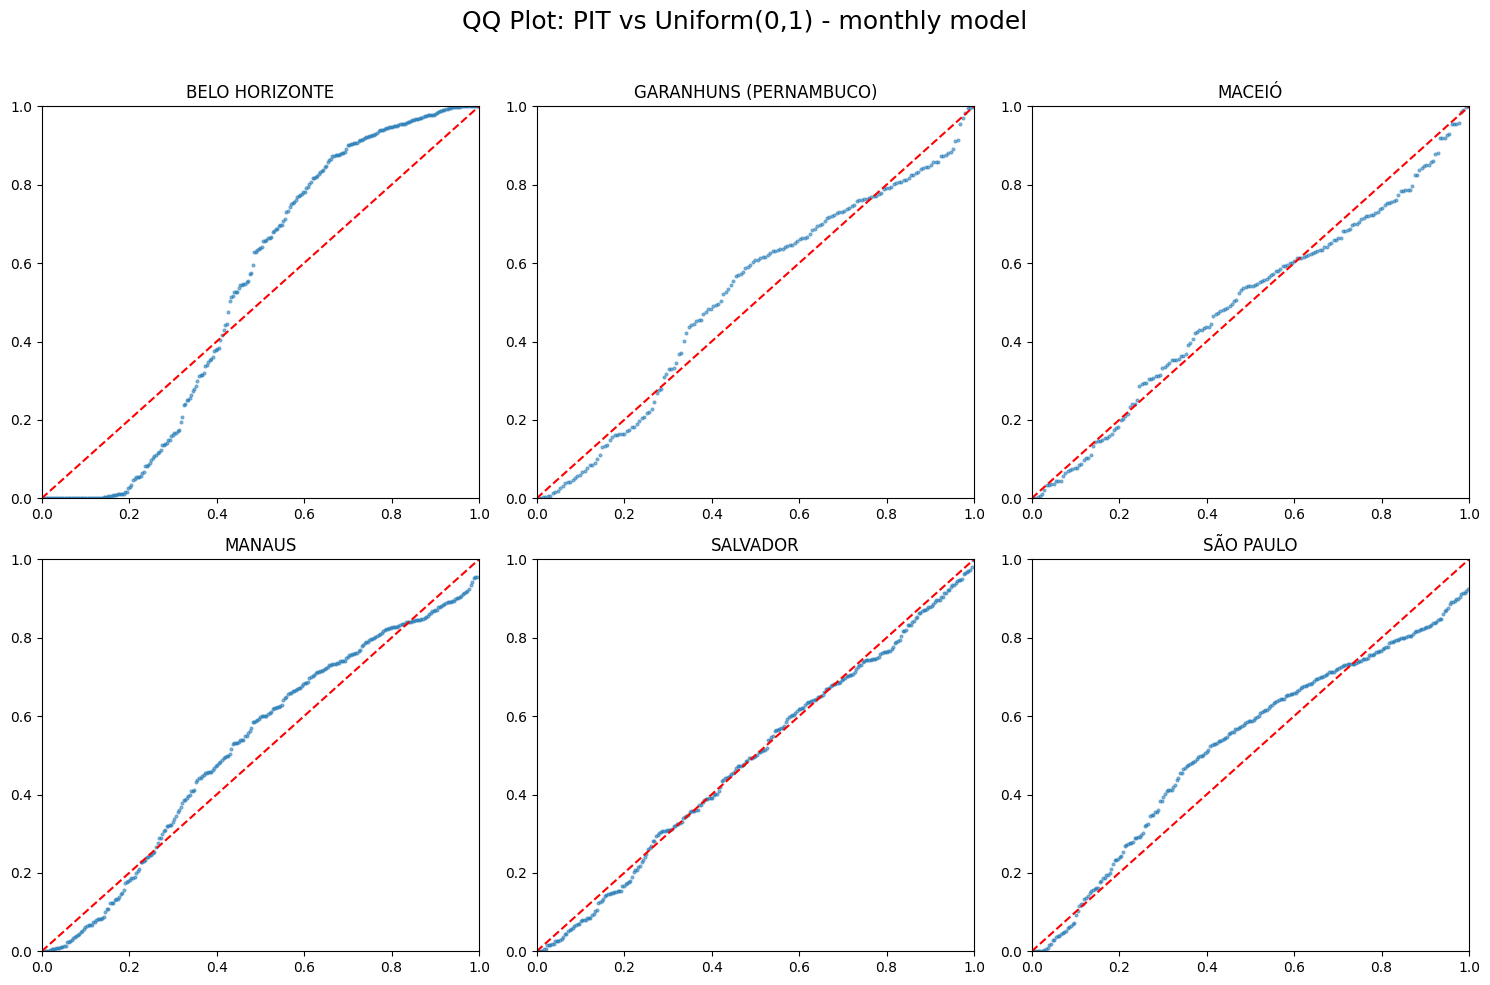

In [199]:
import math
import matplotlib.pyplot as plt

n_models = len(results)
ncols = 3
nrows = math.ceil(n_models / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.axis("off")

for idx_plot, (k, result) in enumerate(results.items()):

    ax = axes[idx_plot]
    res = result[0]

    # --- (your parameter extraction block stays the same) ---
    # assume pit already computed exactly as in your code

    pit_sorted = np.sort(pits[idx_plot])
    n = len(pit_sorted)
    u_theoretical = (np.arange(1, n+1) - 0.5) / n

    ax.plot(u_theoretical, pit_sorted, 'o', alpha=0.5, markersize=2)
    ax.plot([0,1], [0,1], 'r--')
    ax.set_title(k)
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)

fig.suptitle("QQ Plot: PIT vs Uniform(0,1) - monthly model", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("QQ_PIT_mosaic_monthly.png", dpi=300)
plt.show()


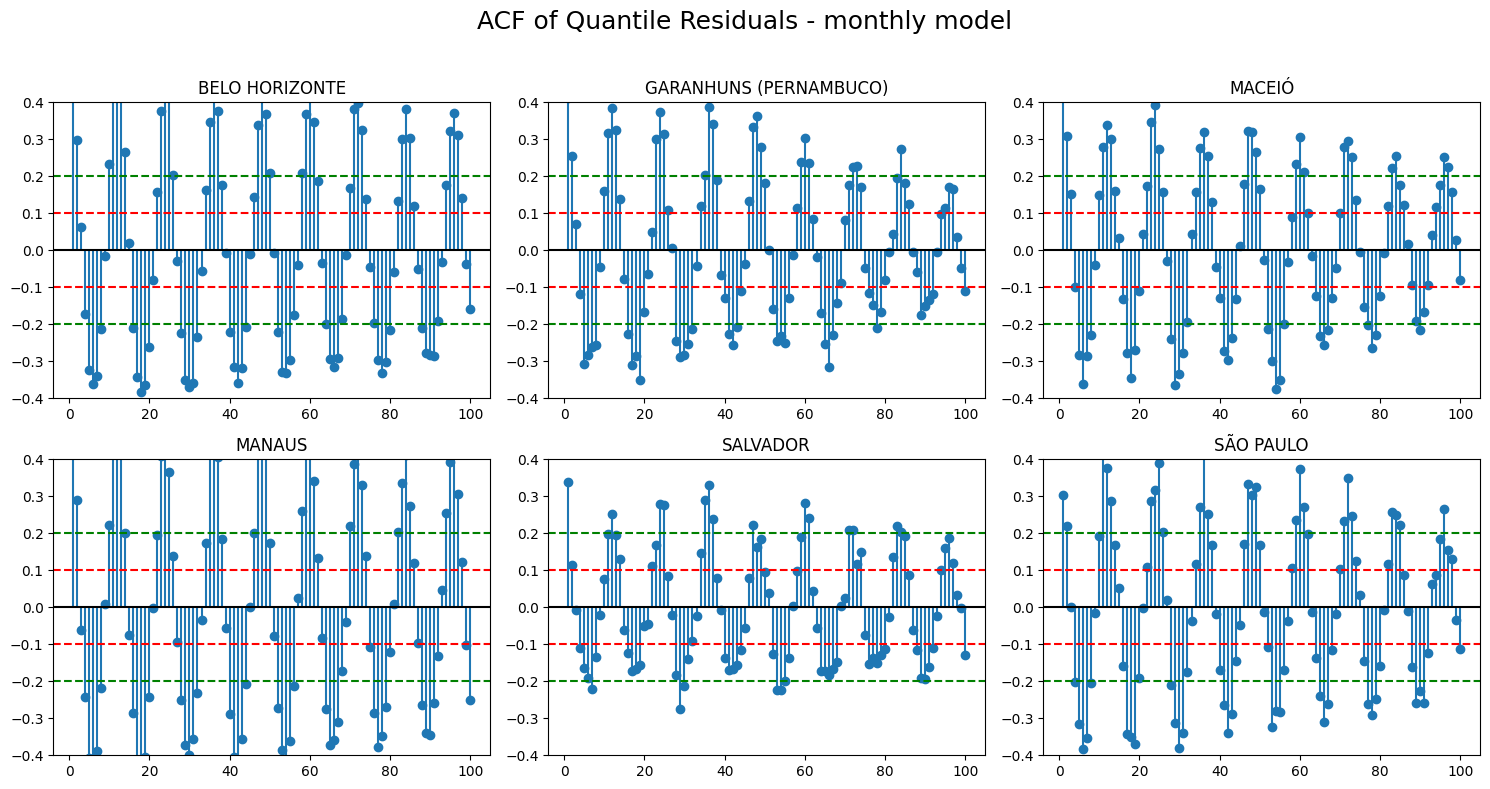

In [200]:
from statsmodels.tsa.stattools import acf

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax in axes[n_models:]:
    ax.axis("off")

for idx_plot, (k, result) in enumerate(results.items()):

    ax = axes[idx_plot]

    qr = quant[idx_plot]  # stored earlier

    nlags = 100  # 400 too crowded in mosaic
    acf_vals = acf(qr, nlags=nlags, fft=True)
    acf_vals_no0 = acf_vals[1:]
    lags = np.arange(1, nlags+1)
    
    conf01 = 0.1
    conf02 = 0.2

    ax.stem(lags, acf_vals_no0, basefmt=" ")
    ax.axhline(0, color="black")
    ax.axhline(conf01, color="red", linestyle="--")
    ax.axhline(-conf01, color="red", linestyle="--")
    ax.axhline(conf02, color="green", linestyle="--")
    ax.axhline(-conf02, color="green", linestyle="--")

    ax.set_title(k)
    ax.set_ylim(-0.4, 0.4)

fig.suptitle("ACF of Quantile Residuals - monthly model", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("ACF_quantile_mosaic_monthly.png", dpi=300)
plt.show()


In [129]:
new_df = dfs[0].groupby('year-month')['precipitation original'].sum()

In [130]:
new_df.to_csv(os.path.join(OUTPUT, 'precipitation_monthly_test_train.csv'), index = False)

In [131]:
new_df

year-month
2000-01    469.5
2000-02    194.0
2000-03    131.4
2000-04     55.1
2000-05      1.5
           ...  
2023-08     31.0
2023-09     15.8
2023-10    163.9
2023-11    113.9
2023-12    158.3
Name: precipitation original, Length: 288, dtype: float64